In [261]:
display(HTML('<h2>KARTHIKEIN MR C72 BATCH</h2>'))

In [262]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE
from statsmodels.graphics.gofplots import qqplot
from tabulate import tabulate
from IPython.display import display, HTML

In [263]:
# Data Understanding
display(HTML('<h2>Data Understanding</h2>'))
display(HTML('<p>This step involves exploring the data to understand its structure, columns, and summary statistics. It includes checking for missing values, data types.</p>'))

# Load the dataset
# Replace 'day.csv' with the actual path to your dataset
data = pd.read_csv('day.csv')

# First five rows of the dataset
print("First five rows of the dataset:")
data.head()

# Data shape and columns
print(f"\nData Shape: {data.shape}")
print(f"Columns: {data.columns}")

# Data summary statistics
print("\nSummary statistics:")
print(data.describe())

# Data types of columns
summary = [
    ["Column", "Non-Null Count", "Dtype"]
] + [[col, str(data[col].notnull().sum()) + ' non-null', str(data[col].dtype)] for col in data.columns]

# Print the table with neat formatting
print(tabulate(summary, headers="firstrow", tablefmt="fancy_grid"))


First five rows of the dataset:

Data Shape: (730, 16)
Columns: Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Summary statistics:
          instant      season          yr        mnth     holiday     weekday  \
count  730.000000  730.000000  730.000000  730.000000  730.000000  730.000000   
mean   365.500000    2.498630    0.500000    6.526027    0.028767    2.995890   
std    210.877136    1.110184    0.500343    3.450215    0.167266    2.000339   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.250000    2.000000    0.000000    4.000000    0.000000    1.000000   
50%    365.500000    3.000000    0.500000    7.000000    0.000000    3.000000   
75%    547.750000    3.000000    1.000000   10.000000    0.000000    5.000000   
max    730.000000    4.000000    1.000000   12.000000    1.0

In [264]:
display(HTML('<h2> Data Quality Checking</h2>'))
display(HTML('<p>check for any missing values or duplicate rows in the dataset. Cleaning the data.</p>'))

# Checking for missing values
print("\nMissing values in the dataset:")
missing_values = data.isnull().sum()

#the missing values in a neat format using tabulate
summary_missing = [["Column", "Missing Values"]] + [[col, missing_values[col]] for col in data.columns]
print(tabulate(summary_missing, headers="firstrow", tablefmt="fancy_grid"))

# Checking for duplicates
print("\nChecking for duplicate rows:")
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")



Missing values in the dataset:
╒════════════╤══════════════════╕
│ Column     │   Missing Values │
╞════════════╪══════════════════╡
│ instant    │                0 │
├────────────┼──────────────────┤
│ dteday     │                0 │
├────────────┼──────────────────┤
│ season     │                0 │
├────────────┼──────────────────┤
│ yr         │                0 │
├────────────┼──────────────────┤
│ mnth       │                0 │
├────────────┼──────────────────┤
│ holiday    │                0 │
├────────────┼──────────────────┤
│ weekday    │                0 │
├────────────┼──────────────────┤
│ workingday │                0 │
├────────────┼──────────────────┤
│ weathersit │                0 │
├────────────┼──────────────────┤
│ temp       │                0 │
├────────────┼──────────────────┤
│ atemp      │                0 │
├────────────┼──────────────────┤
│ hum        │                0 │
├────────────┼──────────────────┤
│ windspeed  │                0 │
├────────────┼──

In [265]:

# Convert categorical variables to meaningful labels
data['season'] = data['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
data['weathersit'] = data['weathersit'].map({1: 'Clear', 2: 'Cloudy', 3: 'Rainy', 4: 'Heavy Rain'})

# Drop unnecessary columns
data = data.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)


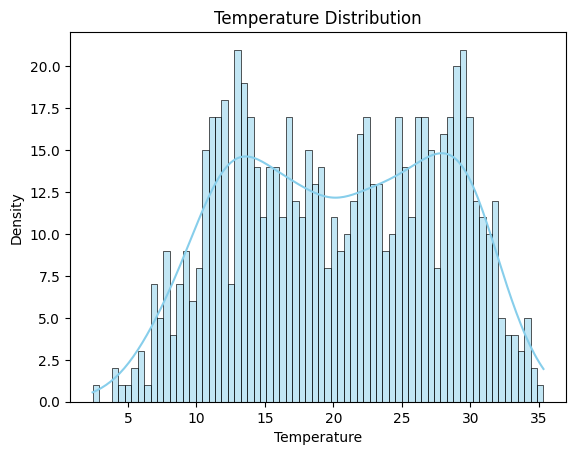

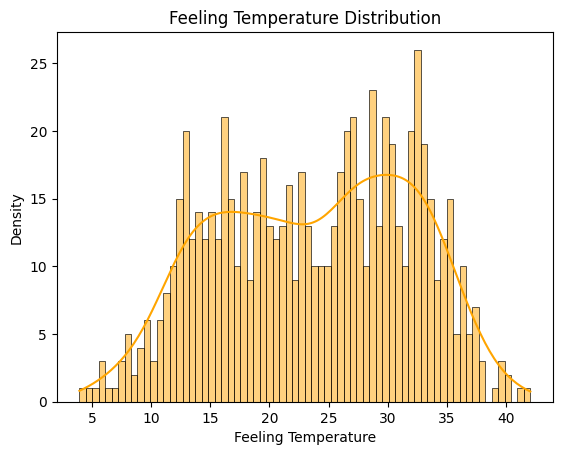

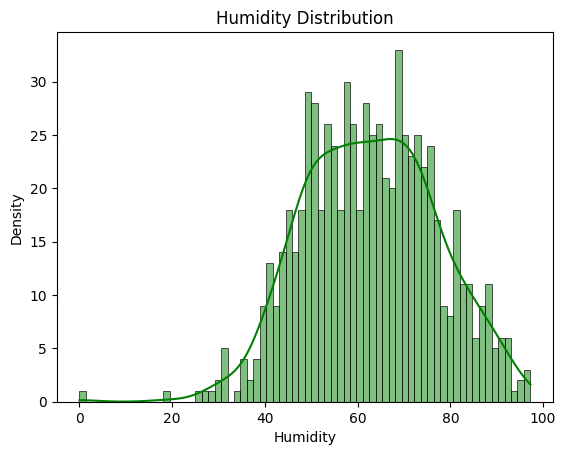

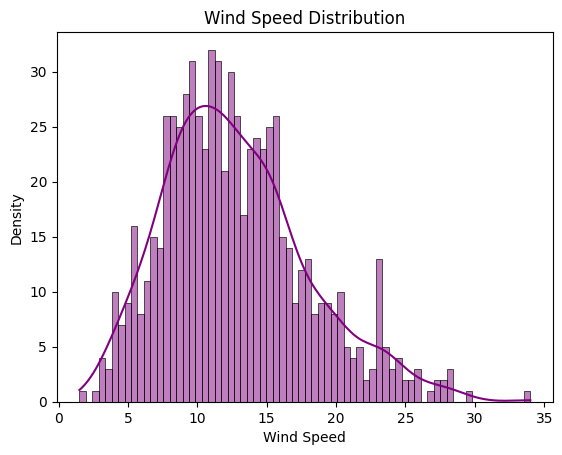

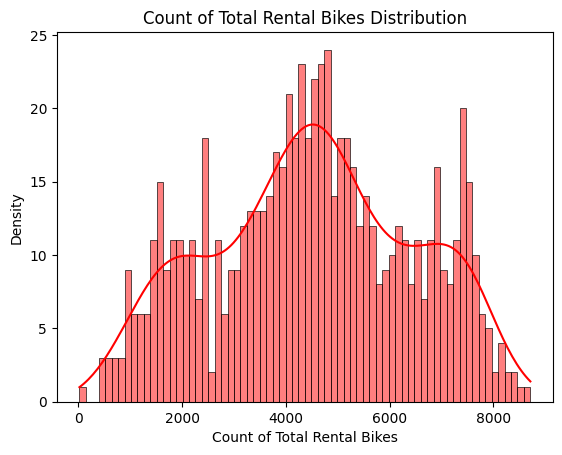

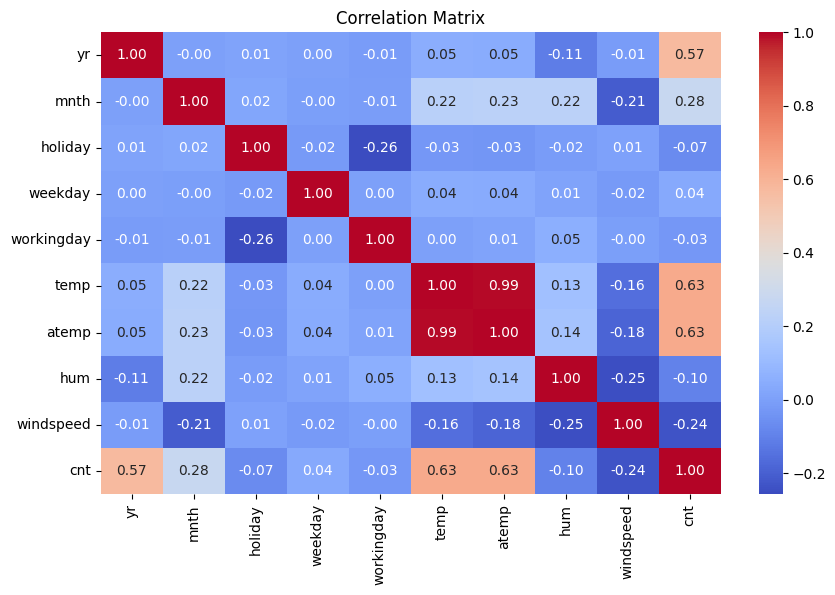

In [266]:
display(HTML('<h2>Exploratory Data Analysis (EDA)</h2>'))
display(HTML('<p>In this step creating heatmaps, pair plots, and distribution plots to uncover patterns in the data.</p>'))
def plot_distribution(feature, color, title, xlabel, ylabel):
    sns.histplot(data[feature], kde=True, bins=70, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()
plot_distribution('temp', 'skyblue', 'Temperature Distribution', 'Temperature', 'Density')
plot_distribution('atemp', 'orange', 'Feeling Temperature Distribution', 'Feeling Temperature', 'Density')
plot_distribution('hum', 'green', 'Humidity Distribution', 'Humidity', 'Density')
plot_distribution('windspeed', 'purple', 'Wind Speed Distribution', 'Wind Speed', 'Density')
plot_distribution('cnt', 'red', 'Count of Total Rental Bikes Distribution', 'Count of Total Rental Bikes', 'Density')

# Plot correlation heatmap only for numeric columns
numeric_data = data.select_dtypes(include=[np.number])  # Select only numeric columns
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()



In [267]:
# Convert categorical columns to dummy variables
data = pd.get_dummies(data, drop_first=True)

# Define Features and Target
X = data.drop('cnt', axis=1)  # Features
y = data['cnt']  # Target variable
# Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [268]:
# Model Building
display(HTML('<h2>Model Building</h2>'))
display(HTML('<p>In machine learning algorithms such as Linear Regression.to build models based on the prepared data. The models will be trained and tested to make predictions on unseen data.</p>'))

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [269]:
display(HTML('<h2> Model Evaluation</h2>'))
display(HTML('<p>After training the model evaluate its performance using metrics such as R-squared.</p>'))
# Predict on the test set
y_pred = model.predict(X_test)
# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"\nR-squared score on the test set: {r2:.3f}")



R-squared score on the test set: 0.849


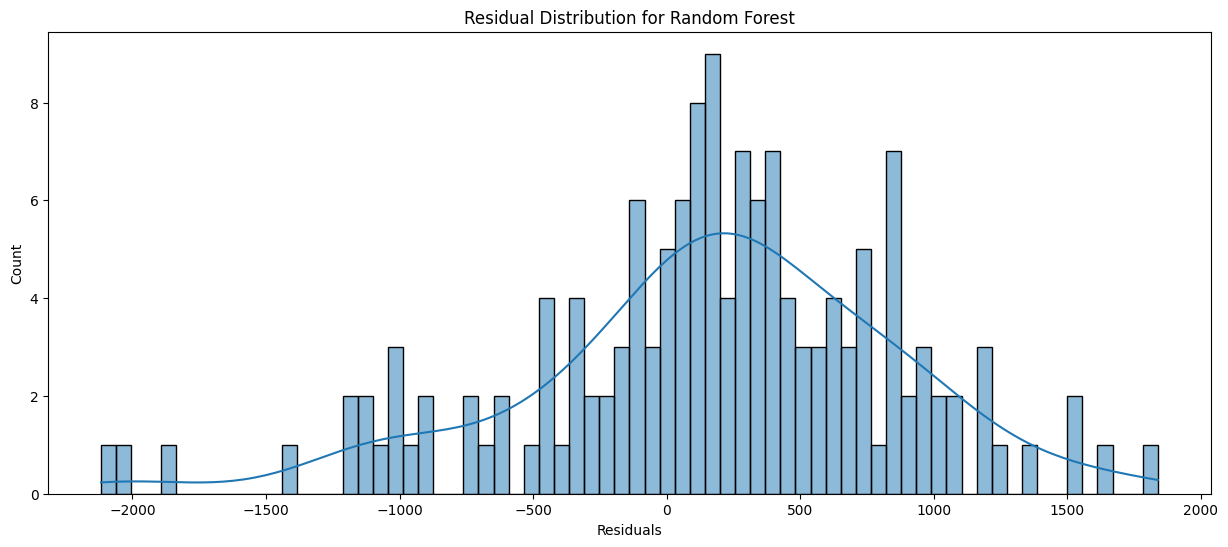

<Figure size 800x600 with 0 Axes>

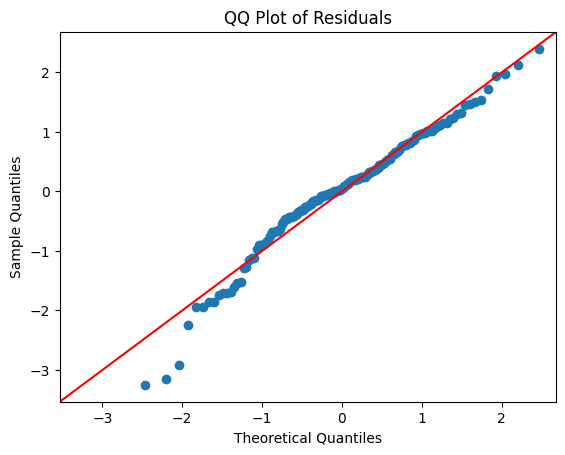

In [270]:
# Residual Analysis
display(HTML('<h2>Residual Analysis</h2>'))
display(HTML('<p>performing residual analysis to check if the residuals follow a normal distribution.</p>'))

# Residual analysis for Random Forest
residuals = y_test - y_pred
plt.figure(figsize=(15, 6))
sns.histplot(residuals, kde=True, bins=70)
plt.title('Residual Distribution for Random Forest')
plt.xlabel('Residuals')
plt.show()

# QQ Plot for residuals
import statsmodels.api as sm
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ Plot of Residuals')
plt.show()


In [271]:
display(HTML('<h2>Test for Normality</h2>'))
display(HTML('<p>The Shapiro-Wilk test is a statistical test used to check if the residuals (errors) of the model are normally distributed. This is an assumption for linear regression. If the p-value is less than 0.05, we reject the null hypothesis that the residuals are normally distributed.</p>'))

shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue < 0.05:
    print("Residuals are NOT normally distributed (p < 0.05).")
else:
    print("Residuals appear to be normally distributed (p >= 0.05).")


Shapiro-Wilk Test Statistic: 0.9708, p-value: 0.0033
Residuals are NOT normally distributed (p < 0.05).


In [272]:
display(HTML('<h2>Model Interpretation</h2>'))
display(HTML('<p>After training the model, we interpret the coefficients of the linear regression model to understand how each feature contributes to the prediction. Larger absolute values of coefficients indicate more significant features.</p>'))
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)  # Replace X_train and y_train with your data

# Now you can interpret the coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

# Display coefficients in a neat table format
print("\nModel Coefficients:")
print(tabulate(coefficients.reset_index(), headers=['Feature', 'Coefficient'], tablefmt='fancy_grid', showindex=False))

# Highlight the most significant features
coefficients['Absolute Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='Absolute Coefficient', ascending=False).head(5)

# Format the DataFrame for neat output
top_features.reset_index(drop=True, inplace=True)

# Display the top 5 features in a neat table format using tabulate
print("\nTop 5 Features Based on Absolute Coefficients:")
print(tabulate(top_features, headers="keys", tablefmt="fancy_grid", showindex=False))



Model Coefficients:
╒═══════════════════╤═══════════════╕
│ Feature           │   Coefficient │
╞═══════════════════╪═══════════════╡
│ yr                │     1987.34   │
├───────────────────┼───────────────┤
│ mnth              │      -29.2873 │
├───────────────────┼───────────────┤
│ holiday           │     -781.259  │
├───────────────────┼───────────────┤
│ weekday           │       21.2854 │
├───────────────────┼───────────────┤
│ workingday        │     -181.841  │
├───────────────────┼───────────────┤
│ temp              │       96.6785 │
├───────────────────┼───────────────┤
│ atemp             │       25.5155 │
├───────────────────┼───────────────┤
│ hum               │      -10.8157 │
├───────────────────┼───────────────┤
│ windspeed         │      -43.0482 │
├───────────────────┼───────────────┤
│ season_Spring     │    -1005.16   │
├───────────────────┼───────────────┤
│ season_Summer     │      243.809  │
├───────────────────┼───────────────┤
│ season_Winter     │      79

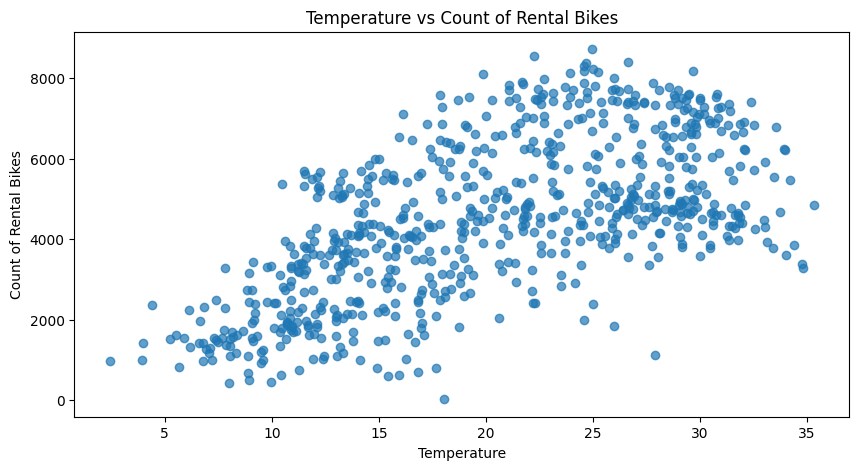

In [273]:
# Visualizing Relationships
display(HTML('<h2>Visualizing Relationships</h2>'))
display(HTML('<p>This step involves visualizing key relationships such as temperature vs. bike rentals or seasonality using boxplots and scatter plots to better understand trends.</p>'))

# Scatter plot: Temperature vs Count of Rental Bikes
plt.figure(figsize=[10, 5])
plt.scatter(data['temp'], data['cnt'], alpha=0.7)
plt.title('Temperature vs Count of Rental Bikes')
plt.xlabel('Temperature')
plt.ylabel('Count of Rental Bikes')
plt.show()


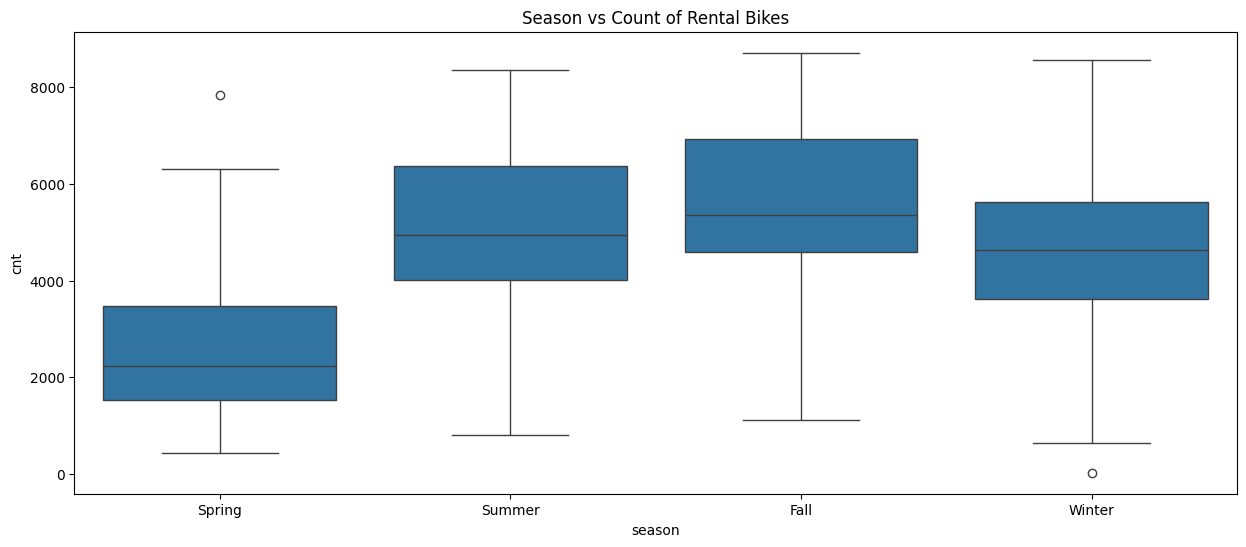

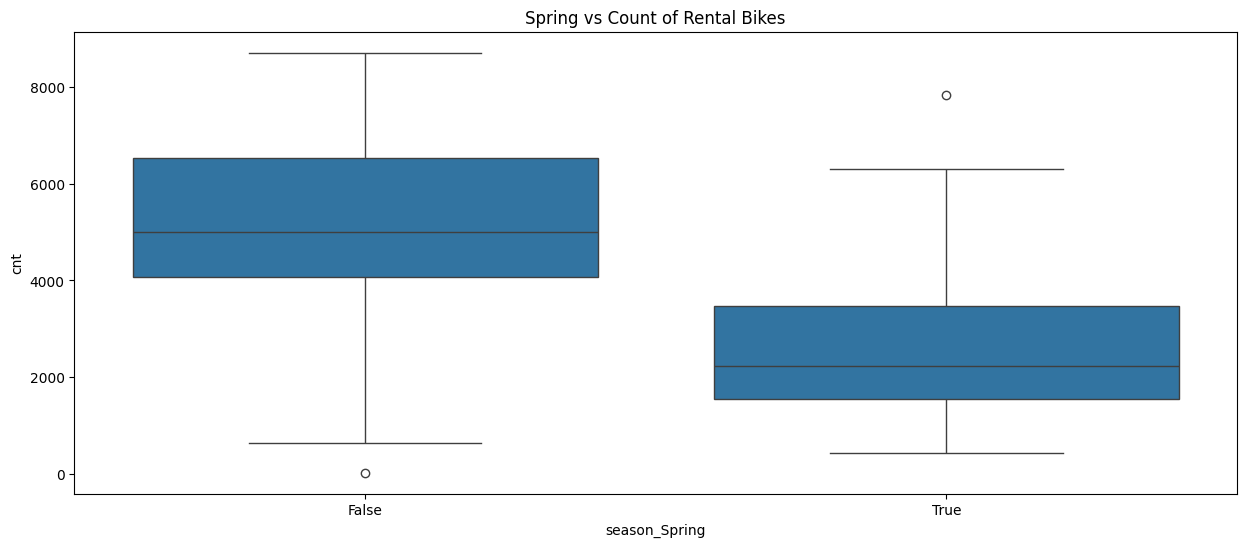

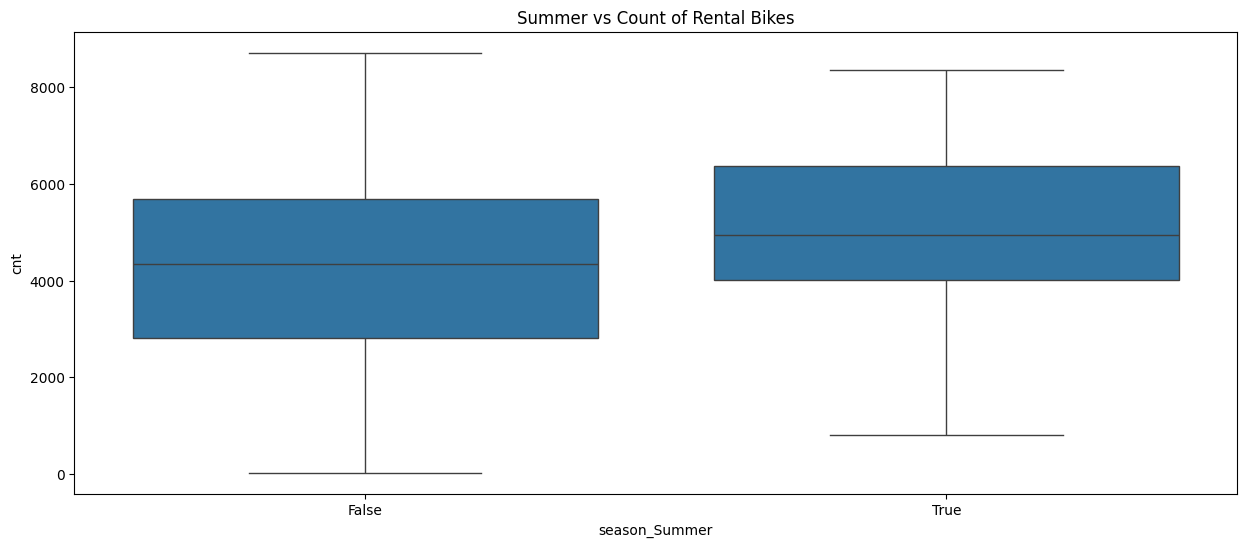

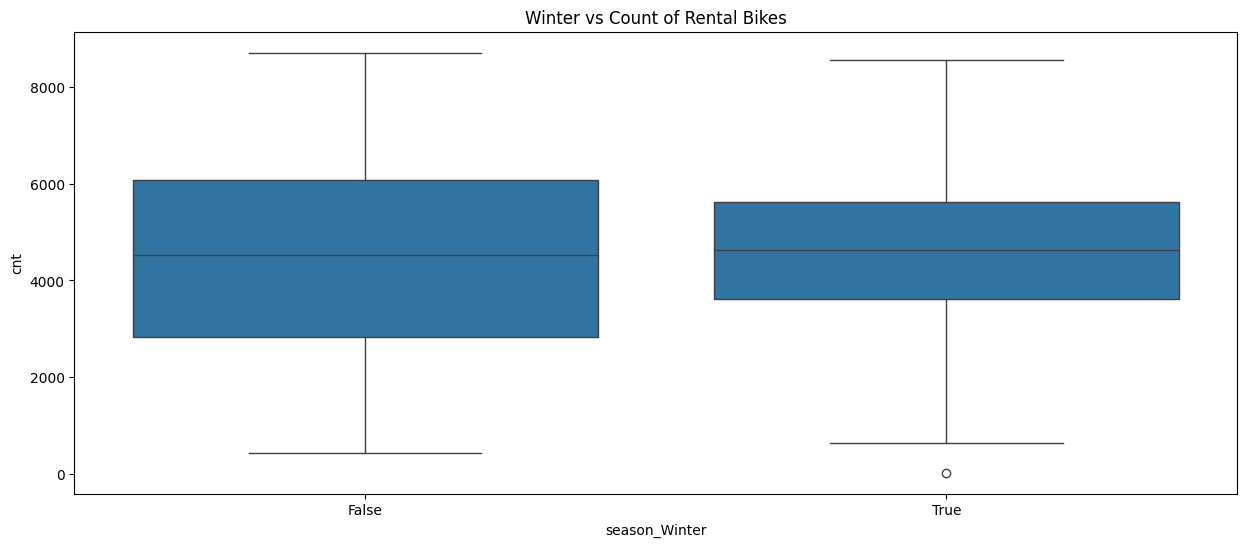

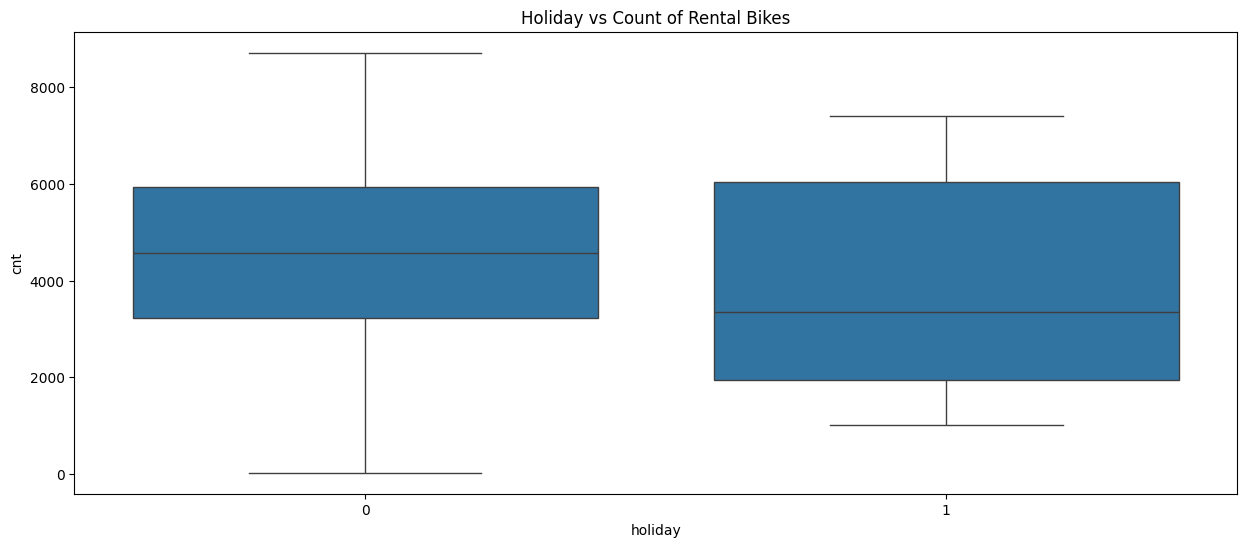

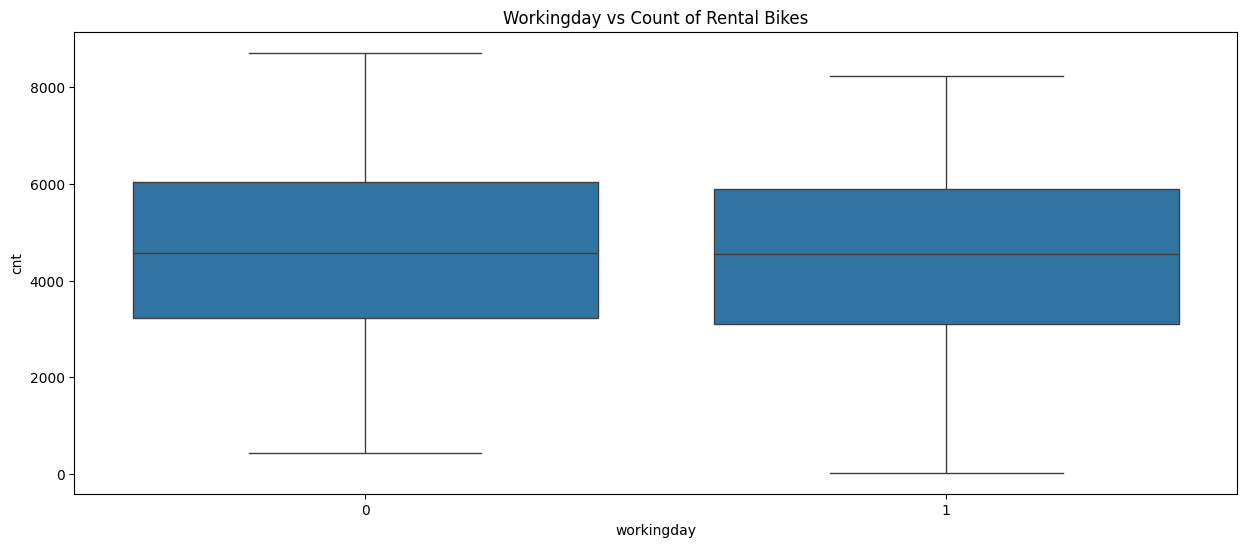

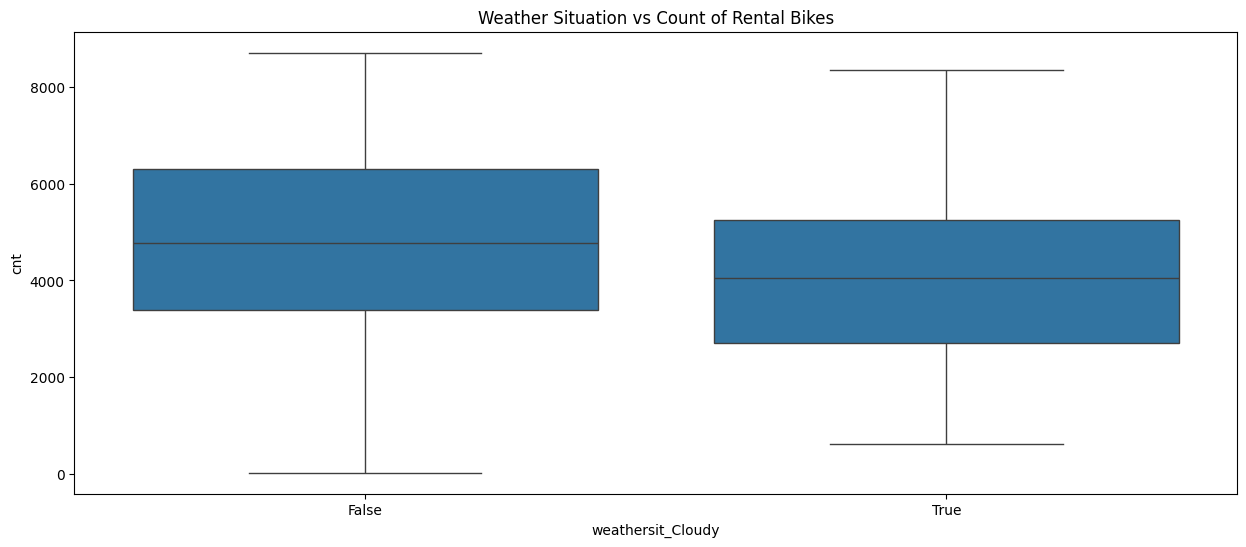

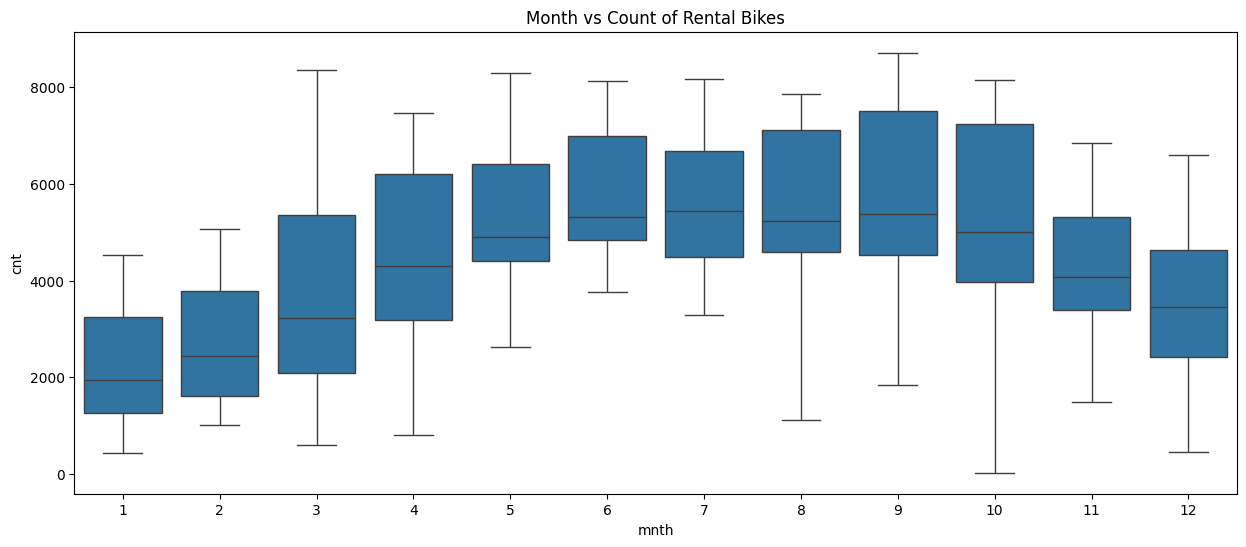

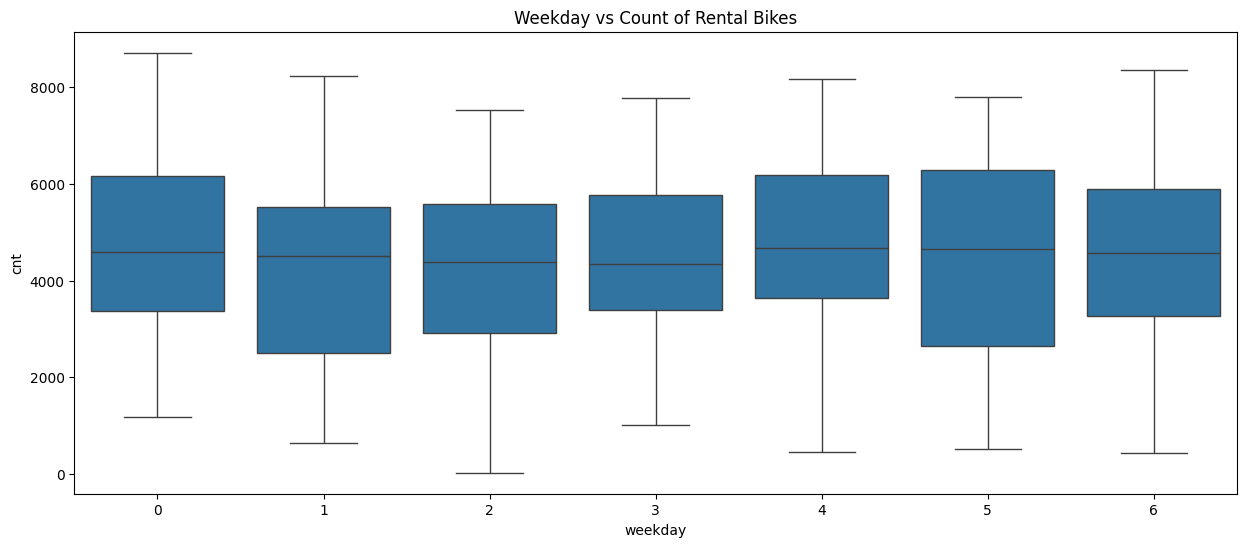

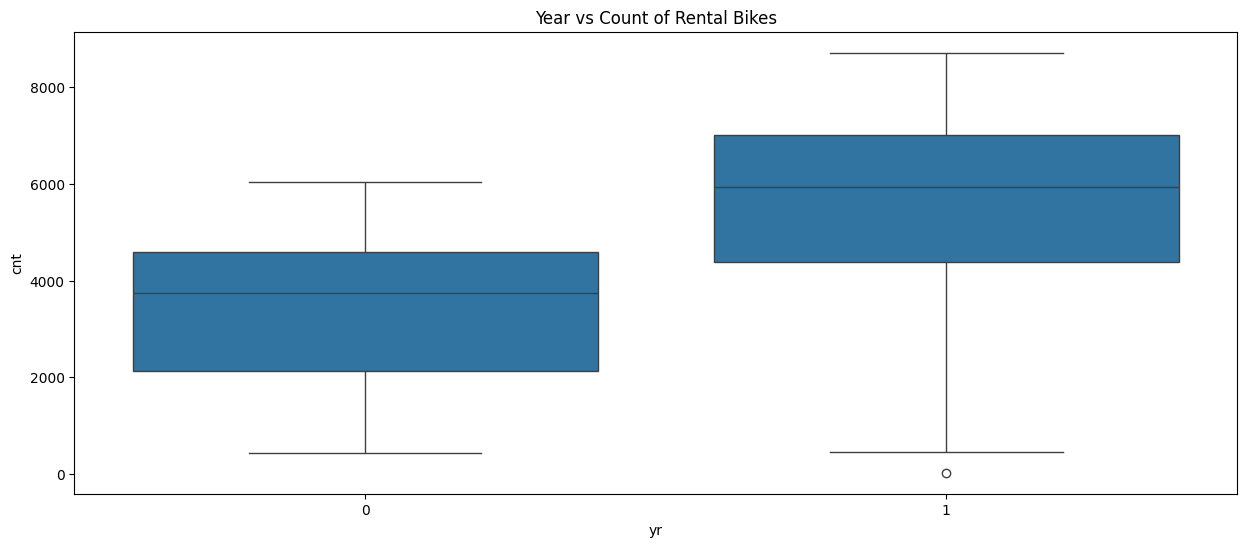

In [274]:
display(HTML('<h2>Recreate the "Season" Column for Better Interpretation</h2>'))
display(HTML('<p>recreate the season feature based on the one-hot encoded columns, making it easier to understand which season corresponds to each observation.</p>'))

def get_season(row):
    if row['season_Spring'] == 1:
        return 'Spring'
    elif row['season_Summer'] == 1:
        return 'Summer'
    elif row['season_Winter'] == 1:
        return 'Winter'
    else:
        return 'Fall'  

data['season'] = data.apply(get_season, axis=1)

# Plotting boxplot for Season vs Count of Rental Bikes
plt.figure(figsize=(15, 6))
sns.boxplot(x='season', y='cnt', data=data)
plt.title('Season vs Count of Rental Bikes')
plt.show()

# Boxplot for specific seasons
display(HTML('<h3>Boxplot for Specific Seasons</h3>'))

# Spring
plt.figure(figsize=(15, 6))
sns.boxplot(x='season_Spring', y='cnt', data=data)
plt.title('Spring vs Count of Rental Bikes')
plt.show()

# Summer
plt.figure(figsize=(15, 6))
sns.boxplot(x='season_Summer', y='cnt', data=data)
plt.title('Summer vs Count of Rental Bikes')
plt.show()

# Winter
plt.figure(figsize=(15, 6))
sns.boxplot(x='season_Winter', y='cnt', data=data)
plt.title('Winter vs Count of Rental Bikes')
plt.show()

# Boxplot for Holiday vs Count
display(HTML('<h3>Boxplot for Holiday vs Count</h3>'))
plt.figure(figsize=(15, 6))
sns.boxplot(x='holiday', y='cnt', data=data)
plt.title('Holiday vs Count of Rental Bikes')
plt.show()

# Boxplot for Working Day vs Count
display(HTML('<h3>Boxplot for Working Day vs Count</h3>'))
plt.figure(figsize=(15, 6))
sns.boxplot(x='workingday', y='cnt', data=data)
plt.title('Workingday vs Count of Rental Bikes')
plt.show()

# Boxplot for Weather Situation vs Count
display(HTML('<h3>Boxplot for Weather Situation vs Count</h3>'))
plt.figure(figsize=(15, 6))
sns.boxplot(x='weathersit_Cloudy', y='cnt', data=data)
plt.title('Weather Situation vs Count of Rental Bikes')
plt.show()

# Boxplot for Month vs Count
display(HTML('<h3>Boxplot for Month vs Count</h3>'))
plt.figure(figsize=(15, 6))
sns.boxplot(x='mnth', y='cnt', data=data)
plt.title('Month vs Count of Rental Bikes')
plt.show()

# Boxplot for Weekday vs Count
display(HTML('<h3>Boxplot for Weekday vs Count</h3>'))
plt.figure(figsize=(15, 6))
sns.boxplot(x='weekday', y='cnt', data=data)
plt.title('Weekday vs Count of Rental Bikes')
plt.show()

# Boxplot for Year vs Count
display(HTML('<h3>Boxplot for Year vs Count</h3>'))
plt.figure(figsize=(15, 6))
sns.boxplot(x='yr', y='cnt', data=data)
plt.title('Year vs Count of Rental Bikes')
plt.show()